# Amazon ML Challenge 2026 — Business Entity Resolution
## Exploratory Data Analysis (EDA)

**Author:** Member 1 — Data + EDA + Evaluation + Integration  
**Date:** 2026-09-26  
**Notebook:** `notebooks/01_eda.ipynb`

---

### Purpose
This notebook performs a thorough exploratory analysis of all 7 TSV datasets:  
- **Train:** `train_source1`, `train_source2`, `train_source3`, `train_ground_truth`  
- **Test:** `test_source1`, `test_source2`, `test_source3`

### Memory & Hardware Constraints
- **CPU:** Intel i3  |  **RAM:** 16 GB  |  **Dataset:** ~2.4 GB raw TSV
- Each source is loaded one at a time, inspected, then released with `del` + `gc.collect()`.
- Chunked iteration (`iter_source_chunks`) is used for large sources where applicable.
- No Cartesian products, no model training, no external APIs.

---

## 1. Imports and Configuration

In [1]:
# Standard library
import gc
import sys
import warnings
from pathlib import Path
from collections import Counter

# Data stack
import numpy as np
import pandas as pd

# Visualisation
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# Project root on sys.path (so 'src' package is importable)
PROJECT_ROOT = Path.cwd().parent   # notebooks/ -> project root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Data-loader imports
from src.business_entity_resolution.data_loader import (
    load_source1,
    load_source2,
    load_source3,
    load_train_ground_truth,
    load_test_source1,
    load_test_source2,
    load_test_source3,
    iter_source_chunks,
    SOURCE_REQUIRED_COLUMNS,
    GROUND_TRUTH_REQUIRED_COLUMNS,
    SOURCE_ID_PREFIX,
)

print('All imports successful.')
print(f'  pandas     {pd.__version__}')
print(f'  numpy      {np.__version__}')
print(f'  matplotlib {matplotlib.__version__}')
print(f'  seaborn    {sns.__version__}')
print(f'  Project root: {PROJECT_ROOT}')

All imports successful.
  pandas     3.0.6
  numpy      2.5.3
  matplotlib 3.11.2
  seaborn    0.13.2
  Project root: c:\Users\hp\Documents\Hackathon\AWS ML Challenge\Aws ML


In [2]:
# Plot styling
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d',
    'axes.labelcolor':  '#e0e4f0',
    'xtick.color':      '#a0a8c0',
    'ytick.color':      '#a0a8c0',
    'text.color':       '#e0e4f0',
    'grid.color':       '#2a2d3d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'axes.titlecolor':  '#ffffff',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'figure.dpi':       110,
})
PALETTE = ['#6c8ebf', '#82c0cc', '#f4a261', '#e76f51', '#2a9d8f', '#e9c46a', '#c77dff']

# EDA chunking budget
CHUNK_SIZE = 100_000   # rows per chunk for large-file scans
SAMPLE_N   = 50_000    # rows sampled for distribution plots

print(f'Chunk size : {CHUNK_SIZE:,} rows')
print(f'Plot sample: {SAMPLE_N:,} rows')

Chunk size : 100,000 rows
Plot sample: 50,000 rows


---
## 2. Dataset Overview

Load each source sequentially, inspect shape / columns / dtypes, then release from memory.

In [3]:
def show_overview(df, label):
    print(f'\n{chr(9472)*60}')
    print(f'  {label}')
    print(f'{chr(9472)*60}')
    print(f'  Shape   : {df.shape[0]:>12,} rows x {df.shape[1]} cols')
    print(f'  Columns : {df.columns.tolist()}')
    print(f'  Dtypes  :')
    for col, dt in df.dtypes.items():
        print(f'    {col:<30} {dt}')
    mem_mb = df.memory_usage(deep=True).sum() / 1e6
    print(f'  Memory  : {mem_mb:.1f} MB')
    print('  Head (3):')
    display(df.head(3))
    return {'label': label, 'rows': df.shape[0], 'cols': df.shape[1], 'mem_mb': round(mem_mb, 1)}

overview_records = []

In [4]:
# train_source1
print('Loading train_source1 ...')
s1_train = load_source1()
overview_records.append(show_overview(s1_train, 'train_source1'))
del s1_train; gc.collect()
print('train_source1 released.')

Loading train_source1 ...

────────────────────────────────────────────────────────────
  train_source1
────────────────────────────────────────────────────────────
  Shape   :    2,206,821 rows x 4 cols
  Columns : ['entity_id', 'business_name', 'business_address', 'country']
  Dtypes  :
    entity_id                      str
    business_name                  str
    business_address               str
    country                        str
  Memory  : 633.8 MB
  Head (3):


,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US


train_source1 released.


In [5]:
# train_source2
print('Loading train_source2 ...')
s2_train = load_source2()
overview_records.append(show_overview(s2_train, 'train_source2'))
del s2_train; gc.collect()
print('train_source2 released.')

Loading train_source2 ...

────────────────────────────────────────────────────────────
  train_source2
────────────────────────────────────────────────────────────
  Shape   :    5,034,616 rows x 4 cols
  Columns : ['entity_id', 'business_name', 'business_address', 'country']
  Dtypes  :
    entity_id                      str
    business_name                  str
    business_address               str
    country                        str
  Memory  : 1487.7 MB
  Head (3):


,entity_id,business_name,business_address,country
0,S2-166376419,राम मार्केटिंग प्राइवेट लिमिटेड,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi",India
1,S2-764573417,-- Holloway Peak Inc Seafood,"105 ELM ST, MORGANTON, NC",US
2,S2-639257739,आदित्य प्रॉपर्टीज एलएलपी,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh",India


train_source2 released.


In [6]:
# train_source3
print('Loading train_source3 ...')
s3_train = load_source3()
overview_records.append(show_overview(s3_train, 'train_source3'))
del s3_train; gc.collect()
print('train_source3 released.')

Loading train_source3 ...

────────────────────────────────────────────────────────────
  train_source3
────────────────────────────────────────────────────────────
  Shape   :    5,285,603 rows x 4 cols
  Columns : ['entity_id', 'business_name', 'business_address', 'country']
  Dtypes  :
    entity_id                      str
    business_name                  str
    business_address               str
    country                        str
  Memory  : 1550.3 MB
  Head (3):


,entity_id,business_name,business_address,country
0,S3-202863386,wilfordhancock.com,"Mack Rd, Haltom City, Texas",US
1,S3-859268022,International South Consultants Private Ltd,NaN,India
2,S3-22467283,LLC Moncada Léarning Center,"5780 Fawn Ct, Fort Worth, Texas",US


train_source3 released.


In [7]:
# train_ground_truth
print('Loading train_ground_truth ...')
gt_train = load_train_ground_truth()
overview_records.append(show_overview(gt_train, 'train_ground_truth'))
del gt_train; gc.collect()
print('train_ground_truth released.')

Loading train_ground_truth ...

────────────────────────────────────────────────────────────
  train_ground_truth
────────────────────────────────────────────────────────────
  Shape   :    2,206,821 rows x 2 cols
  Columns : ['source1_entity_id', 'matched_entity_ids']
  Dtypes  :
    source1_entity_id              str
    matched_entity_ids             str
  Memory  : 336.8 MB
  Head (3):


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"


train_ground_truth released.


In [8]:
# test_source1
print('Loading test_source1 ...')
s1_test = load_test_source1()
overview_records.append(show_overview(s1_test, 'test_source1'))
del s1_test; gc.collect()
print('test_source1 released.')

Loading test_source1 ...

────────────────────────────────────────────────────────────
  test_source1
────────────────────────────────────────────────────────────
  Shape   :    1,732,544 rows x 4 cols
  Columns : ['entity_id', 'business_name', 'business_address', 'country']
  Dtypes  :
    entity_id                      str
    business_name                  str
    business_address               str
    country                        str
  Memory  : 509.5 MB
  Head (3):


,entity_id,business_name,business_address,country
0,S1-714132312,Zephay Labs Inc,"2621 Cotten Road, Tyler, TX",US
1,S1-106407869,Vision Partners Corp,"IA, Iowa City, 1064 Newton Rd, Unit 11",US
2,S1-156285671,<< Team Ecole,"175 Boulevard du Président Franklin Roosevelt,...",France


test_source1 released.


In [9]:
# test_source2
print('Loading test_source2 ...')
s2_test = load_test_source2()
overview_records.append(show_overview(s2_test, 'test_source2'))
del s2_test; gc.collect()
print('test_source2 released.')

Loading test_source2 ...

────────────────────────────────────────────────────────────
  test_source2
────────────────────────────────────────────────────────────
  Shape   :    4,887,273 rows x 4 cols
  Columns : ['entity_id', 'business_name', 'business_address', 'country']
  Dtypes  :
    entity_id                      str
    business_name                  str
    business_address               str
    country                        str
  Memory  : 1488.7 MB
  Head (3):


,entity_id,business_name,business_address,country
0,S2-192345572,Brahma Infosoft,"COIMATORE COLONY, HUNSUR TQMYSORE DIST., Karna...",India
1,S2-566025912,Marina Ecole France Sarl,"63 R. DE DIEPPE, LILLE, Hauts-de-France",France
2,S2-158121477,SCI Ptit Àmicale,"18 RUE JEN ZAY, Dunkerque, Nord",France


test_source2 released.


In [10]:
# test_source3
print('Loading test_source3 ...')
s3_test = load_test_source3()
overview_records.append(show_overview(s3_test, 'test_source3'))
del s3_test; gc.collect()
print('test_source3 released.')

Loading test_source3 ...

────────────────────────────────────────────────────────────
  test_source3
────────────────────────────────────────────────────────────
  Shape   :    5,082,316 rows x 4 cols
  Columns : ['entity_id', 'business_name', 'business_address', 'country']
  Dtypes  :
    entity_id                      str
    business_name                  str
    business_address               str
    country                        str
  Memory  : 1523.0 MB
  Head (3):


,entity_id,business_name,business_address,country
0,S3-462677478,मॉडर्न फाइनेंस,"No 10 Enkay Square, 448A, Udyog Vihar Phase V,...",India
1,S3-374810425,Shri Sai Infratech Co,"3/115, East Delhi, DL",India
2,S3-198586129,Fractales Amis Groupe S.A.S,"23 Rue Icmre, La Teste-de-buch, Gironde",France


test_source3 released.


In [11]:
# Summary table
overview_df = pd.DataFrame(overview_records)
overview_df['rows_fmt'] = overview_df['rows'].apply(lambda x: f'{x:,}')
overview_df['mem_fmt']  = overview_df['mem_mb'].apply(lambda x: f'{x:.1f} MB')
print('Dataset Summary')
display(overview_df[['label', 'rows_fmt', 'cols', 'mem_fmt']].rename(
    columns={'label': 'Dataset', 'rows_fmt': 'Rows', 'cols': 'Columns', 'mem_fmt': 'In-RAM Size'}
))
del overview_df; gc.collect()

Dataset Summary


,Dataset,Rows,Columns,In-RAM Size
0,train_source1,"2,206,821",4,633.8 MB
1,train_source2,"5,034,616",4,1487.7 MB
2,train_source3,"5,285,603",4,1550.3 MB
3,train_ground_truth,"2,206,821",2,336.8 MB
4,test_source1,"1,732,544",4,509.5 MB
5,test_source2,"4,887,273",4,1488.7 MB
6,test_source3,"5,082,316",4,1523.0 MB


0

---
## 3. Missing Values

Compute missing counts and percentages per column for each source, focusing on `business_name`, `business_address`, and `country`.

In [12]:
def missing_report(df, label):
    total = len(df)
    miss  = df.isnull().sum()
    pct   = (miss / total * 100).round(4)
    report = pd.DataFrame({
        'column': miss.index,
        'missing_count': miss.values,
        'missing_pct': pct.values
    })
    report['source'] = label
    print(f'\nMissing values --- {label}')
    display(report.set_index('column')[['missing_count', 'missing_pct']])
    for col in ['business_name', 'business_address']:
        if col in df.columns:
            ws_only = df[col].dropna().str.strip().eq('').sum()
            print(f"  '{col}' whitespace-only: {ws_only:,} ({ws_only/total*100:.3f}%)")
    return report

In [13]:
s1_train = load_source1()
missing_report(s1_train, 'train_source1')
del s1_train; gc.collect()


Missing values --- train_source1


,missing_count,missing_pct
column,,
entity_id,0,0.0
business_name,0,0.0
business_address,0,0.0
country,0,0.0


  'business_name' whitespace-only: 0 (0.000%)
  'business_address' whitespace-only: 0 (0.000%)


0

In [14]:
s2_train = load_source2()
missing_report(s2_train, 'train_source2')
del s2_train; gc.collect()


Missing values --- train_source2


,missing_count,missing_pct
column,,
entity_id,0,0.0000
business_name,2,0.0000
business_address,168967,3.3561
country,0,0.0000


  'business_name' whitespace-only: 0 (0.000%)
  'business_address' whitespace-only: 0 (0.000%)


0

In [15]:
s3_train = load_source3()
missing_report(s3_train, 'train_source3')
del s3_train; gc.collect()


Missing values --- train_source3


,missing_count,missing_pct
column,,
entity_id,0,0.0000
business_name,13,0.0002
business_address,175916,3.3282
country,0,0.0000


  'business_name' whitespace-only: 0 (0.000%)
  'business_address' whitespace-only: 0 (0.000%)


0

In [16]:
s1_test = load_test_source1()
missing_report(s1_test, 'test_source1')
del s1_test; gc.collect()


Missing values --- test_source1


,missing_count,missing_pct
column,,
entity_id,0,0.0
business_name,0,0.0
business_address,0,0.0
country,0,0.0


  'business_name' whitespace-only: 0 (0.000%)
  'business_address' whitespace-only: 0 (0.000%)


0

In [17]:
s2_test = load_test_source2()
missing_report(s2_test, 'test_source2')
del s2_test; gc.collect()


Missing values --- test_source2


,missing_count,missing_pct
column,,
entity_id,0,0.0000
business_name,46,0.0009
business_address,129408,2.6479
country,0,0.0000


  'business_name' whitespace-only: 0 (0.000%)
  'business_address' whitespace-only: 0 (0.000%)


0

In [18]:
s3_test = load_test_source3()
missing_report(s3_test, 'test_source3')
del s3_test; gc.collect()
print('All missing-value inspections complete.')


Missing values --- test_source3


,missing_count,missing_pct
column,,
entity_id,0,0.0000
business_name,59,0.0012
business_address,136098,2.6779
country,0,0.0000


  'business_name' whitespace-only: 0 (0.000%)
  'business_address' whitespace-only: 0 (0.000%)
All missing-value inspections complete.


---
## 4. Duplicate Analysis

Check unique vs. duplicate `entity_id` counts and duplicate business names / addresses using efficient grouped summaries (no all-pairs loops).

In [19]:
def duplicate_report(df, label):
    total   = len(df)
    uniq_id = df['entity_id'].nunique()
    dup_id  = total - uniq_id
    print(f'\nDuplicate Analysis --- {label}')
    print(f'  Total rows           : {total:>12,}')
    print(f'  Unique entity_ids    : {uniq_id:>12,}')
    print(f'  Duplicate entity_ids : {dup_id:>12,}  ({dup_id/total*100:.3f}%)')

    if 'business_name' in df.columns:
        name_vc  = df['business_name'].value_counts()
        dup_n    = (name_vc > 1).sum()
        print(f'\n  business_name distinct  : {len(name_vc):,}')
        print(f'  business_name with >1 occurrence: {dup_n:,}')
        print('  Top-5 most frequent names:')
        for nm, cnt in name_vc.head(5).items():
            print(f'    {cnt:6,}x  {str(nm)[:70]}')
        del name_vc

    if 'business_address' in df.columns:
        addr_vc  = df['business_address'].value_counts()
        dup_a    = (addr_vc > 1).sum()
        print(f'\n  business_address distinct  : {len(addr_vc):,}')
        print(f'  business_address with >1 occurrence: {dup_a:,}')
        print('  Top-5 most frequent addresses:')
        for ad, cnt in addr_vc.head(5).items():
            print(f'    {cnt:6,}x  {str(ad)[:70]}')
        del addr_vc

    gc.collect()

In [20]:
s1_train = load_source1()
duplicate_report(s1_train, 'train_source1')
del s1_train; gc.collect()


Duplicate Analysis --- train_source1
  Total rows           :    2,206,821
  Unique entity_ids    :    2,206,821
  Duplicate entity_ids :            0  (0.000%)

  business_name distinct  : 1,539,229
  business_name with >1 occurrence: 177,793
  Top-5 most frequent names:
       253x  Primary Care Group
       251x  Ear Nose & Throat Group
       222x  Pediatric Group
       220x  Womens Health Group
       218x  Physical Therapy Group

  business_address distinct  : 2,130,606
  business_address with >1 occurrence: 40,089
  Top-5 most frequent addresses:
        14x  108 Norle Street, College Twp, PA
        13x  104 Roadrunner Circle, Elephant Butte, NM
        13x  218 Phillips Street, Storm Lake, IA
        13x  43 Franklin Street, Delaware, OH
        13x  55, Lavkush Vihar, Singhpur, Kachhar Bithoor Road, Kalyanpur, Kanpur N


0

In [21]:
s2_train = load_source2()
duplicate_report(s2_train, 'train_source2')
del s2_train; gc.collect()


Duplicate Analysis --- train_source2
  Total rows           :    5,034,616
  Unique entity_ids    :    5,034,616
  Duplicate entity_ids :            0  (0.000%)

  business_name distinct  : 4,402,008
  business_name with >1 occurrence: 239,778
  Top-5 most frequent names:
       320x  Primary Care
       307x  Physical Therapy
       297x  Urgent Care
       297x  Womens Health
       296x  Behavioral Health

  business_address distinct  : 4,337,261
  business_address with >1 occurrence: 421,472
  Top-5 most frequent addresses:
        18x  842 38, CALEDONAI TOWNSHIP, WI
        18x  1948 WEAVER FOREST WAY, MORRISVILLE, NC
        17x  66 FRANK EDGE, ALTO, TX
        16x  G-58/1, BENSON CROSS ROAD, BANGALORE., Karnataka
        16x  302 REGENCY CT, AMES, IA


0

In [22]:
s3_train = load_source3()
duplicate_report(s3_train, 'train_source3')
del s3_train; gc.collect()


Duplicate Analysis --- train_source3
  Total rows           :    5,285,603
  Unique entity_ids    :    5,285,603
  Duplicate entity_ids :            0  (0.000%)

  business_name distinct  : 4,651,608
  business_name with >1 occurrence: 258,275
  Top-5 most frequent names:
       421x  Primary Care
       399x  Physical Therapy
       393x  Pediatric Dental
       379x  Womens Health
       377x  Urgent Care

  business_address distinct  : 4,632,764
  business_address with >1 occurrence: 382,890
  Top-5 most frequent addresses:
        29x  Ground Floor, Bangalore, KA
        26x  Floor, Mumbai, MH
        26x  18, Kolkata, Howrah, WB
        25x  303, Mumbai, MH
        23x  12, Ahmedabad, GJ


0

---
## 5. Entity ID Validation

Exhaustive prefix validation using chunked iteration to stay within RAM limits. Reports anomaly counts and observed prefix distributions.

In [23]:
def validate_ids_chunked(source_name, split, expected_prefix):
    label         = f'{split}_{source_name}'
    total_rows    = 0
    anomaly_count = 0
    anomaly_examples = []
    prefix_counter   = Counter()

    for chunk in iter_source_chunks(source_name, split,
                                    chunksize=CHUNK_SIZE,
                                    usecols=['entity_id']):
        total_rows += len(chunk)
        bad_mask = ~chunk['entity_id'].str.startswith(expected_prefix, na=False)
        bad_rows = chunk[bad_mask]
        anomaly_count += len(bad_rows)
        if len(anomaly_examples) < 10:
            anomaly_examples.extend(bad_rows['entity_id'].head(5).tolist())
        prefix_counter.update(
            chunk['entity_id'].dropna().str[:3].value_counts().to_dict()
        )

    status = 'PASS' if anomaly_count == 0 else f'FAIL ({anomaly_count:,} anomalies)'
    print(f'  {label:<25}  rows={total_rows:>10,}  prefix_check={status}')
    if anomaly_examples:
        print(f'    Anomaly examples: {anomaly_examples[:5]}')
    print(f'    Observed prefixes (top-3): {prefix_counter.most_common(3)}')
    gc.collect()
    return {'source': label, 'total_rows': total_rows, 'anomalies': anomaly_count}

print('Entity ID Prefix Validation (exhaustive chunked scan)')
print('=' * 65)
id_results = []
for src, split_name, prefix in [
    ('source1', 'train', 'S1-'), ('source2', 'train', 'S2-'), ('source3', 'train', 'S3-'),
    ('source1', 'test',  'S1-'), ('source2', 'test',  'S2-'), ('source3', 'test',  'S3-'),
]:
    id_results.append(validate_ids_chunked(src, split_name, prefix))

print('=' * 65)
display(pd.DataFrame(id_results))
del id_results; gc.collect()

Entity ID Prefix Validation (exhaustive chunked scan)
  train_source1              rows= 2,206,821  prefix_check=PASS
    Observed prefixes (top-3): [('S1-', 2206821)]
  train_source2              rows= 5,034,616  prefix_check=PASS
    Observed prefixes (top-3): [('S2-', 5034616)]
  train_source3              rows= 5,285,603  prefix_check=PASS
    Observed prefixes (top-3): [('S3-', 5285603)]
  test_source1               rows= 1,732,544  prefix_check=PASS
    Observed prefixes (top-3): [('S1-', 1732544)]
  test_source2               rows= 4,887,273  prefix_check=PASS
    Observed prefixes (top-3): [('S2-', 4887273)]
  test_source3               rows= 5,082,316  prefix_check=PASS
    Observed prefixes (top-3): [('S3-', 5082316)]


,source,total_rows,anomalies
0,train_source1,2206821,0
1,train_source2,5034616,0
2,train_source3,5285603,0
3,test_source1,1732544,0
4,test_source2,4887273,0
5,test_source3,5082316,0


0

---
## 6. Country Distribution

Calculate open-set string counts and percentages for `country` across all train and test sources. Includes a lightweight bar chart.

In [24]:
def get_country_counts_chunked(source_name, split):
    counter = Counter()
    for chunk in iter_source_chunks(source_name, split,
                                    chunksize=CHUNK_SIZE,
                                    usecols=['country']):
        counter.update(chunk['country'].value_counts(dropna=False).to_dict())
    gc.collect()
    return pd.Series(dict(counter)).sort_values(ascending=False)

country_data = {}
for src, split_name in [
    ('source1', 'train'), ('source2', 'train'), ('source3', 'train'),
    ('source1', 'test'),  ('source2', 'test'),  ('source3', 'test'),
]:
    key = f'{split_name}_{src}'
    print(f'  Scanning: {key} ...')
    country_data[key] = get_country_counts_chunked(src, split_name)

print('Country aggregation complete.')

  Scanning: train_source1 ...
  Scanning: train_source2 ...
  Scanning: train_source3 ...
  Scanning: test_source1 ...
  Scanning: test_source2 ...
  Scanning: test_source3 ...
Country aggregation complete.


In [25]:
for key, series in country_data.items():
    total = series.sum()
    df_c  = pd.DataFrame({'count': series, 'pct': (series / total * 100).round(2)})
    print(f'\nCountry distribution --- {key}  (unique values: {len(series)}, total rows: {total:,})')
    display(df_c.head(20))
    del df_c
gc.collect()


Country distribution --- train_source1  (unique values: 2, total rows: 2,206,821)


,count,pct
US,1323633,59.98
India,883188,40.02



Country distribution --- train_source2  (unique values: 2, total rows: 5,034,616)


,count,pct
US,3016817,59.92
India,2017799,40.08



Country distribution --- train_source3  (unique values: 2, total rows: 5,285,603)


...


Country distribution --- test_source2  (unique values: 3, total rows: 4,887,273)


,count,pct
India,2312565,47.32
US,1871330,38.29
France,703378,14.39



Country distribution --- test_source3  (unique values: 3, total rows: 5,082,316)


,count,pct
India,2405000,47.32
US,1945701,38.28
France,731615,14.40


0

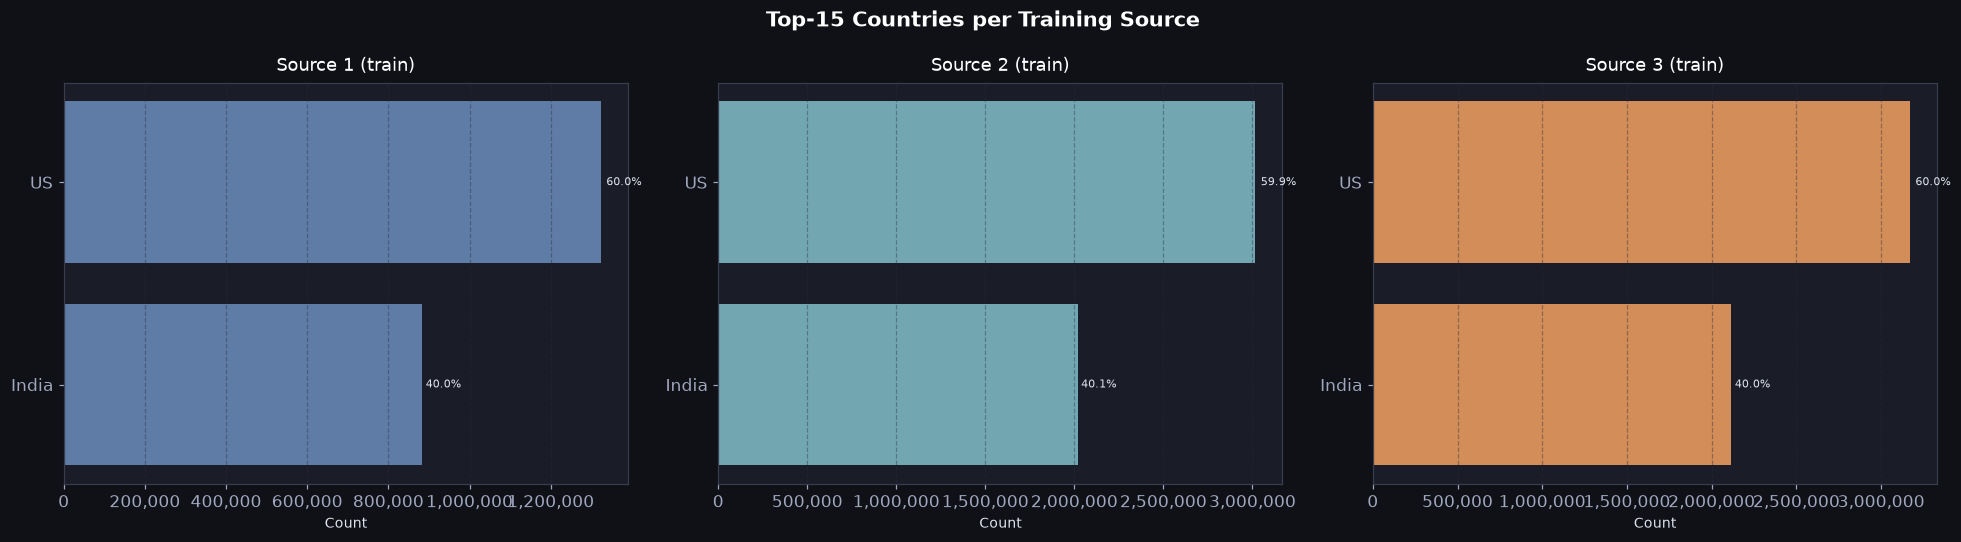

Chart saved: output/eda_country_distribution.png


29

In [26]:
# Bar chart: top-15 countries per training source
TOP_N = 15
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Top-15 Countries per Training Source', color='#ffffff', fontsize=14, fontweight='bold')

for ax, (i, key) in zip(axes, enumerate(['train_source1', 'train_source2', 'train_source3'])):
    series = country_data[key].head(TOP_N)
    total  = country_data[key].sum()
    pct    = (series / total * 100).round(1)
    bars   = ax.barh(series.index[::-1], series.values[::-1],
                     color=PALETTE[i], alpha=0.85)
    ax.set_title(f'Source {i+1} (train)', fontsize=12, pad=8)
    ax.set_xlabel('Count', fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(axis='x', alpha=0.4)
    for bar, p in zip(bars, pct.values[::-1]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{p:.1f}%', va='center', ha='left', fontsize=7.5, color='#e0e4f0')

plt.tight_layout()
plt.savefig('../output/eda_country_distribution.png',
            dpi=110, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart saved: output/eda_country_distribution.png')
del country_data; gc.collect()

---
## 7. Business Name Analysis

Compute text-length distributions (min, max, mean, median, percentiles) and check empty/whitespace-only names. Inspect representative rows.

In [27]:
def name_length_stats_chunked(source_name, split):
    reservoir = []
    RESERVOIR_LIMIT = 200_000
    min_len = float('inf')
    max_len = 0
    total = 0
    null_count = 0
    ws_only_count = 0

    for chunk in iter_source_chunks(source_name, split,
                                    chunksize=CHUNK_SIZE,
                                    usecols=['business_name']):
        null_count    += chunk['business_name'].isna().sum()
        valid          = chunk['business_name'].dropna()
        ws_only_count += valid.str.strip().eq('').sum()
        lengths        = valid.str.len()
        total         += len(lengths)
        if len(lengths) > 0:
            min_len = min(min_len, int(lengths.min()))
            max_len = max(max_len, int(lengths.max()))
            rem = RESERVOIR_LIMIT - len(reservoir)
            if rem > 0:
                reservoir.extend(
                    lengths.sample(min(rem, len(lengths)), random_state=42).tolist()
                )

    arr = np.array(reservoir, dtype=np.int32)
    result = {
        'source': f'{split}_{source_name}',
        'total_non_null': total,
        'null': int(null_count),
        'whitespace_only': int(ws_only_count),
        'min':    int(min_len) if min_len != float('inf') else None,
        'max':    int(max_len),
        'mean':   round(float(arr.mean()), 2) if len(arr) else None,
        'median': float(np.median(arr)) if len(arr) else None,
        'p25':    float(np.percentile(arr, 25)) if len(arr) else None,
        'p75':    float(np.percentile(arr, 75)) if len(arr) else None,
        'p95':    float(np.percentile(arr, 95)) if len(arr) else None,
        'p99':    float(np.percentile(arr, 99)) if len(arr) else None,
    }
    del arr, reservoir
    gc.collect()
    return result

print('Computing business_name length statistics (chunked) ...')
name_stats_list = []
for src, spl in [
    ('source1', 'train'), ('source2', 'train'), ('source3', 'train'),
    ('source1', 'test'),  ('source2', 'test'),  ('source3', 'test'),
]:
    print(f'  -> {spl}_{src}')
    name_stats_list.append(name_length_stats_chunked(src, spl))

display(pd.DataFrame(name_stats_list).set_index('source').round(1))
del name_stats_list; gc.collect()

Computing business_name length statistics (chunked) ...
  -> train_source1
  -> train_source2
  -> train_source3
  -> test_source1
  -> test_source2
  -> test_source3


,total_non_null,null,whitespace_only,min,max,mean,median,p25,p75,p95,p99
source,,,,,,,,,,,
train_source1,2206821,0,0,3,105,24.1,24.0,18.0,30.0,37.0,42.0
train_source2,5034614,2,0,2,104,25.1,25.0,18.0,31.0,40.0,48.0
train_source3,5285590,13,0,2,123,25.2,25.0,18.0,31.0,42.0,50.0
test_source1,1732544,0,0,3,92,23.8,24.0,18.0,29.0,36.0,42.0
test_source2,4887227,46,0,2,102,25.7,25.0,19.0,32.0,41.0,49.0
test_source3,5082257,59,0,2,103,25.6,25.0,19.0,32.0,42.0,50.0


0

In [29]:
# Representative name samples from train_source1
print('Business name samples from train_source1:')
s1_train = load_source1()

display(s1_train.dropna(subset=['business_name'])
                .sample(n=min(12, len(s1_train)), random_state=7)
                .reset_index(drop=True))

short = s1_train[s1_train['business_name'].str.len() <= 5]
print(f'\nVery short names (<=5 chars): {len(short):,}')
display(short.head(8).reset_index(drop=True))

long = s1_train[s1_train['business_name'].str.len() >= 200]
print(f'\nVery long names (>=200 chars): {len(long):,}')
if not long.empty:
    display(long[['entity_id', 'business_name']].head(5).reset_index(drop=True))

del s1_train, short, long; gc.collect()

Business name samples from train_source1:


,entity_id,business_name,business_address,country
0,S1-143205451,Seal & Sons Associates,"Bldg No.1, Fl No.5, F No.504/A, Lotus Sanskrut...",India
1,S1-697347685,Jackson Total Starry Inc,"2430 23rd Street, Henrico County, VA",US
2,S1-832591575,Good Exports Private Limited,"Shop No. 1, Basement Floor, United Medicine Co...",India
3,S1-105982737,Electricians Local 210,"1275 5, Unit Unit 52, Elbridge, NY",US
4,S1-451092852,Kackley Minerals,"805 Ford Street, Joiner, AR",US
5,S1-119103715,Celebrity Management (India) Private Limited,"9062/17 Rani Bagh Road Pul Bangesh, Azad Marke...",India
6,S1-675888289,Al Apex Infrastructure Private Limited,"No. 78, 3Rd Main Road, Ramanjaneya Layout Mara...",India
7,S1-685157977,"Hester Kim Optimal Atlanta, LLC","7400 Gainey Club Drive, Unit UNIT 136, Scottsd...",US
8,S1-996022607,C/B Pimco LP,"2583 Birch Court, Milton, WA",US
9,S1-162343011,Toify LLC,"1004 Marlin Street, Village Of Holmen, WI",US



Very short names (<=5 chars): 6,252


,entity_id,business_name,business_address,country
0,S1-553712807,Meon,"2221 24th Street, Muskogee, OK",US
1,S1-642038314,Proum,"2248 Nelson Drive, Niskayuna, NY",US
2,S1-941259582,Faor,"9036 Willow Trace Court, NC, Huntersville",US
3,S1-274128166,Buus,"GA, Atlanta, 455 Ontario Avenue",US
4,S1-517800727,Minoo,"883 Max View Drive, Parker, AZ",US
5,S1-932911903,Meex,"3659 Vermilion Court, Eagan, MN",US
6,S1-132535915,Ceque,"2140 Palace Avenue, Saint Paul, MN",US
7,S1-36237806,Peum,"408 Brant Road, Corolla, NC",US



Very long names (>=200 chars): 0


851

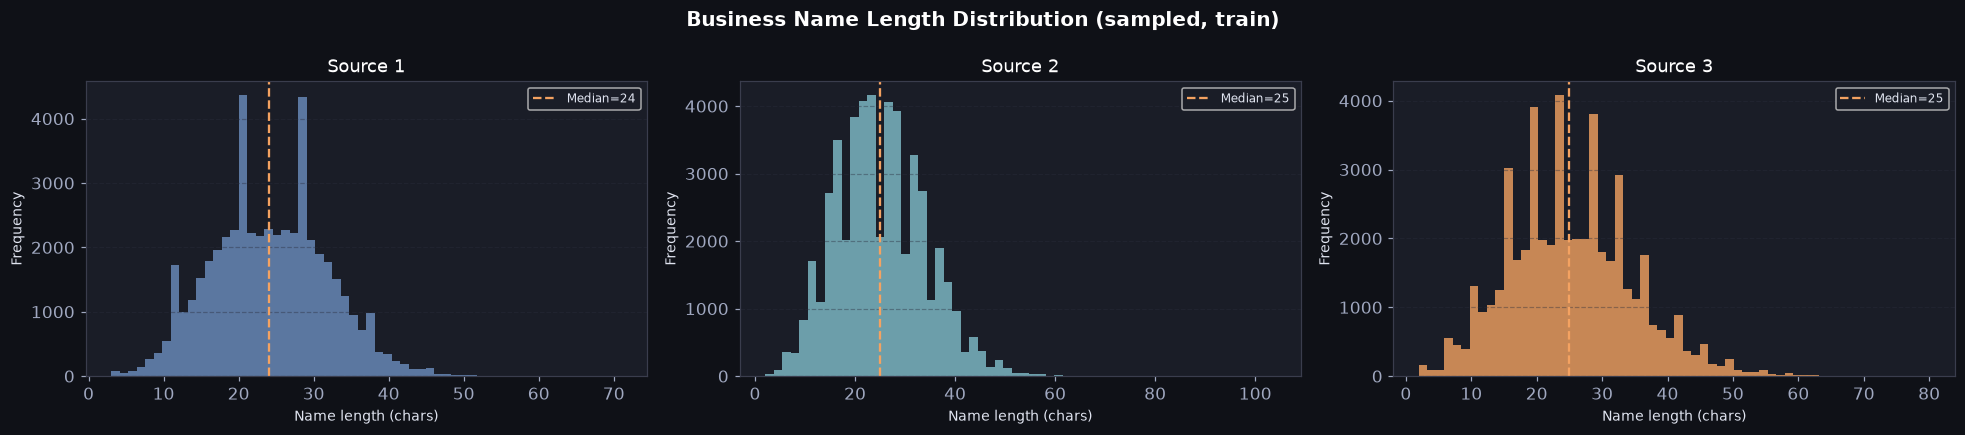

Chart saved: output/eda_name_length_distribution.png


5

In [30]:
# Name length histogram (sampled from all three training sources)
HIST_SAMPLE = 50_000
length_samples = {}

for src in ['source1', 'source2', 'source3']:
    buf = []
    for chunk in iter_source_chunks(src, 'train', chunksize=CHUNK_SIZE, usecols=['business_name']):
        lens = chunk['business_name'].dropna().str.len()
        rem  = HIST_SAMPLE - len(buf)
        if rem > 0 and len(lens) > 0:
            buf.extend(lens.sample(min(rem, len(lens)), random_state=42).tolist())
        if len(buf) >= HIST_SAMPLE:
            break
    length_samples[src] = np.array(buf, dtype=np.int32)
    del buf; gc.collect()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Business Name Length Distribution (sampled, train)',
             color='#ffffff', fontsize=13, fontweight='bold')

for ax, (i, src) in zip(axes, enumerate(['source1', 'source2', 'source3'])):
    data = np.clip(length_samples[src], 0, 300)
    ax.hist(data, bins=60, color=PALETTE[i], alpha=0.8, edgecolor='none')
    ax.set_title(f'Source {i+1}', fontsize=12)
    ax.set_xlabel('Name length (chars)', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    med = float(np.median(length_samples[src]))
    ax.axvline(med, color='#f4a261', lw=1.5, linestyle='--', label=f'Median={med:.0f}')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('../output/eda_name_length_distribution.png',
            dpi=110, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart saved: output/eda_name_length_distribution.png')
del length_samples; gc.collect()

---
## 8. Address Analysis

Compute address-length distributions, missing components, and formatting peculiarities through summary statistics and text samples.

In [31]:
def address_stats_chunked(source_name, split):
    reservoir = []
    RESERVOIR_LIMIT = 200_000
    min_len = float('inf')
    max_len = 0
    total = 0
    null_count = 0
    ws_only_count = 0
    no_digit_count = 0
    all_upper_count = 0

    for chunk in iter_source_chunks(source_name, split,
                                    chunksize=CHUNK_SIZE,
                                    usecols=['business_address']):
        null_count     += chunk['business_address'].isna().sum()
        valid           = chunk['business_address'].dropna()
        ws_only_count  += valid.str.strip().eq('').sum()
        no_digit_count += (~valid.str.contains(r'\d', regex=True)).sum()
        all_upper_count += valid.str.isupper().sum()
        lengths         = valid.str.len()
        total          += len(lengths)
        if len(lengths) > 0:
            min_len = min(min_len, int(lengths.min()))
            max_len = max(max_len, int(lengths.max()))
            rem = RESERVOIR_LIMIT - len(reservoir)
            if rem > 0:
                reservoir.extend(
                    lengths.sample(min(rem, len(lengths)), random_state=42).tolist()
                )

    arr = np.array(reservoir, dtype=np.int32)
    result = {
        'source': f'{split}_{source_name}',
        'total_non_null': total,
        'null': int(null_count),
        'whitespace_only': int(ws_only_count),
        'no_digit': int(no_digit_count),
        'all_uppercase': int(all_upper_count),
        'min':    int(min_len) if min_len != float('inf') else None,
        'max':    int(max_len),
        'mean':   round(float(arr.mean()), 2) if len(arr) else None,
        'median': float(np.median(arr)) if len(arr) else None,
        'p25':    float(np.percentile(arr, 25)) if len(arr) else None,
        'p75':    float(np.percentile(arr, 75)) if len(arr) else None,
        'p95':    float(np.percentile(arr, 95)) if len(arr) else None,
    }
    del arr, reservoir
    gc.collect()
    return result

print('Computing business_address statistics (chunked) ...')
addr_stats_list = []
for src, spl in [
    ('source1', 'train'), ('source2', 'train'), ('source3', 'train'),
    ('source1', 'test'),  ('source2', 'test'),  ('source3', 'test'),
]:
    print(f'  -> {spl}_{src}')
    addr_stats_list.append(address_stats_chunked(src, spl))

display(pd.DataFrame(addr_stats_list).set_index('source').round(1))
del addr_stats_list; gc.collect()

Computing business_address statistics (chunked) ...
  -> train_source1
  -> train_source2
  -> train_source3
  -> test_source1
  -> test_source2
  -> test_source3


,total_non_null,null,whitespace_only,no_digit,all_uppercase,min,max,mean,median,p25,p75,p95
source,,,,,,,,,,,,
train_source1,2206821,0,0,77037,4,11,256,52.1,41.0,33.0,70.0,103.0
train_source2,4865649,168967,0,301974,3191104,8,249,47.9,37.0,31.0,63.0,97.0
train_source3,5109687,175916,0,310390,813,2,240,48.4,42.0,35.0,55.0,92.0
test_source1,1732544,0,0,71838,2,11,268,57.1,50.0,36.0,74.0,105.0
test_source2,4757865,129408,0,228622,2448518,5,269,51.8,43.0,32.0,68.0,99.0
test_source3,4946218,136098,0,245395,914,5,267,50.0,44.0,36.0,59.0,94.0


0

In [33]:
# Address text samples from train_source1
print('Address samples from train_source1:')
s1_train = load_source1()
valid_addr = s1_train.dropna(subset=['business_address'])

display(valid_addr.sample(n=min(8, len(valid_addr)), random_state=42).reset_index(drop=True))

no_digit = valid_addr[~valid_addr['business_address'].str.contains(r'\d', regex=True)]
print(f'\nAddresses without any digit (formatting anomaly): {len(no_digit):,}')
display(no_digit.head(6).reset_index(drop=True))

del s1_train, valid_addr, no_digit; gc.collect()

Address samples from train_source1:


,entity_id,business_name,business_address,country
0,S1-53356671,Pediatric Medicine PLLC,"4850 20, Otisco, NY",US
1,S1-320151505,Fetech National Twin,"19034 Woodburn Road, Woodburn, IN",US
2,S1-938947364,General Design Innovations LLC,"7241 Osage Avenue, Mesa, AZ",US
3,S1-195839862,Construction Ideaz Papers Private Limited,"Building No.4/606, Prabhul Cottage Karimbalur,...",India
4,S1-655046555,Penaloza and Bittle First Inc.,"4255 Charleswood Avenue, Memphis, TN",US
5,S1-758070915,National Investments LLC,"1641 Virginia Lane, Hueytown, AL",US
6,S1-169338169,Reus Idaho Company,"Sanford, ME, 31 Guillemette Street",US
7,S1-796421498,Creative Projects Limited,"12Thfloor, C, 1204, Roya Oasis, Jankalyan Naga...",India



Addresses without any digit (formatting anomaly): 77,037


,entity_id,business_name,business_address,country
0,S1-269656551,Impetus Hotel Public Limited,"Canal Road Wakdai Nagar, Mangaon, Raigarh, Mah...",India
1,S1-913301865,Technologies Pratyaksh Finserve Limited,"Village Kurali, Sabhapur Road Tehsil Bilaspur....",India
2,S1-684656443,Green Ventures Ltd,"P. O. Ranasan, Ta. Talod, Ranasan, Sabar Kanth...",India
3,S1-703200453,Vt Exporters,"C/O Safinara Khatun, Allpara, Ratua, Malda, We...",India
4,S1-173971969,Hotel It Pvt Ltd,"Kailash Bihari Singh, Cou, Po-Bhagwan, Chapra,...",India
5,S1-596450212,Bally Jagachha Management Private Limited,"Ideal Grand Bl-A, G T Road(South) Howrah, Ball...",India


2287

---
## 9. Ground-Truth Match Analysis *(Critical Section)*

Analyse `matched_entity_ids` for every Source 1 entity. Calculate the frequency distribution of match counts (0, 1, 2, 3, 4+ matches) and their respective percentages.

In [34]:
print('Loading ground truth ...')
gt = load_train_ground_truth()
print(f'  Shape: {gt.shape}')
display(gt.head(5))

def parse_matches(raw):
    if pd.isna(raw) or str(raw).strip() == '':
        return []
    return [x.strip() for x in str(raw).split(',') if x.strip()]

gt['match_list']  = gt['matched_entity_ids'].apply(parse_matches)
gt['match_count'] = gt['match_list'].apply(len)

print(f'\nTotal S1 entities : {len(gt):,}')
print(f'Total match pairs : {gt["match_count"].sum():,}')

Loading ground truth ...
  Shape: (2206821, 2)


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."



Total S1 entities : 2,206,821
Total match pairs : 7,638,365


,match_count_bucket,entity_count,percentage
0,0,123247,5.585
1,1,119157,5.399
2,2,375212,17.002
3,3,530841,24.055
4,4+,1058364,47.959


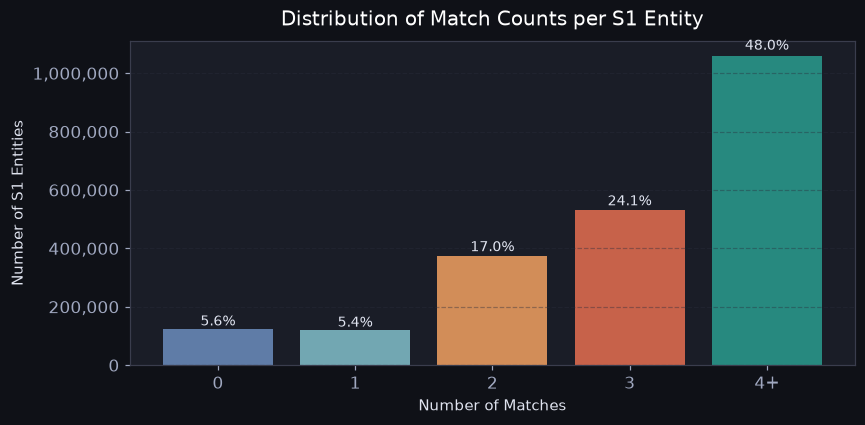

Chart saved: output/eda_match_count_distribution.png


6585

In [35]:
# Frequency distribution of match counts
def bin_count(n):
    return str(n) if n <= 3 else '4+'

gt['match_bin'] = gt['match_count'].apply(bin_count)
bin_order = ['0', '1', '2', '3', '4+']
bin_cts   = gt['match_bin'].value_counts().reindex(bin_order, fill_value=0)
bin_pcts  = (bin_cts / len(gt) * 100).round(3)

display(pd.DataFrame({
    'match_count_bucket': bin_cts.index,
    'entity_count': bin_cts.values,
    'percentage': bin_pcts.values,
}))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(bin_cts.index, bin_cts.values, color=PALETTE[:5], alpha=0.85)
ax.set_title('Distribution of Match Counts per S1 Entity',
             fontsize=13, pad=10, color='#ffffff')
ax.set_xlabel('Number of Matches', fontsize=10)
ax.set_ylabel('Number of S1 Entities', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.4)
for bar, pct in zip(bars, bin_pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, color='#e0e4f0')
plt.tight_layout()
plt.savefig('../output/eda_match_count_distribution.png',
            dpi=110, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart saved: output/eda_match_count_distribution.png')
del bars; gc.collect()

---
## 10. Match Source Distribution

Determine whether matches originate from Source 2 only, Source 3 only, or both sources.

,category,count,pct
0,both_S2_S3,1776047,80.480
1,S3_only,164498,7.454
2,S2_only,143029,6.481
3,no_match,123247,5.585


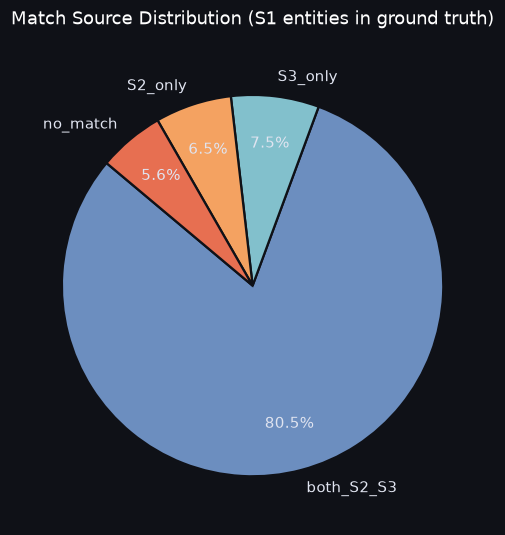

Chart saved: output/eda_match_source_distribution.png


16

In [36]:
def classify_match_source(match_list):
    if not match_list:
        return 'no_match'
    has_s2 = any(m.startswith('S2-') for m in match_list)
    has_s3 = any(m.startswith('S3-') for m in match_list)
    if has_s2 and has_s3:
        return 'both_S2_S3'
    elif has_s2:
        return 'S2_only'
    elif has_s3:
        return 'S3_only'
    return 'unknown_prefix'

gt['match_source'] = gt['match_list'].apply(classify_match_source)
src_dist = gt['match_source'].value_counts()
src_pct  = (src_dist / len(gt) * 100).round(3)

display(pd.DataFrame({'category': src_dist.index, 'count': src_dist.values, 'pct': src_pct.values}))

# Pie chart
fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    src_dist.values,
    labels=src_dist.index,
    autopct='%1.1f%%',
    colors=PALETTE[:len(src_dist)],
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'linewidth': 1.5, 'edgecolor': '#0f1117'},
)
for t in texts + autotexts:
    t.set_color('#e0e4f0'); t.set_fontsize(10)
ax.set_title('Match Source Distribution (S1 entities in ground truth)',
             fontsize=12, color='#ffffff', pad=15)
plt.tight_layout()
plt.savefig('../output/eda_match_source_distribution.png',
            dpi=110, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart saved: output/eda_match_source_distribution.png')
gc.collect()

---
## 11. Match Count Statistics

Compute mean, median, max, and percentiles of match counts per S1 entity to flag extreme outliers.

In [37]:
mc = gt['match_count']
stats_dict = {
    'count (S1 entities)': int(len(mc)),
    'sum (total matches)': int(mc.sum()),
    'mean':   round(float(mc.mean()), 4),
    'std':    round(float(mc.std()),  4),
    'min':    int(mc.min()),
    'p10':    float(mc.quantile(0.10)),
    'p25':    float(mc.quantile(0.25)),
    'median': float(mc.median()),
    'p75':    float(mc.quantile(0.75)),
    'p90':    float(mc.quantile(0.90)),
    'p95':    float(mc.quantile(0.95)),
    'p99':    float(mc.quantile(0.99)),
    'max':    int(mc.max()),
}
print('Match Count Statistics:')
for k, v in stats_dict.items():
    print(f'  {k:<28} : {v}')

p99_threshold = mc.quantile(0.99)
outliers = gt[mc > p99_threshold]
print(f'\n  Entities with match_count > p99 ({p99_threshold:.0f}): {len(outliers):,}')
if not outliers.empty:
    display(outliers[['source1_entity_id', 'match_count']]
            .sort_values('match_count', ascending=False).head(10).reset_index(drop=True))
del outliers; gc.collect()

Match Count Statistics:
  count (S1 entities)          : 2206821
  sum (total matches)          : 7638365
  mean                         : 3.4613
  std                          : 1.7053
  min                          : 0
  p10                          : 1.0
  p25                          : 2.0
  median                       : 3.0
  p75                          : 5.0
  p90                          : 6.0
  p95                          : 6.0
  p99                          : 8.0
  max                          : 11

  Entities with match_count > p99 (8): 4,776


,source1_entity_id,match_count
0,S1-806895726,11
1,S1-971572082,11
2,S1-958050134,11
3,S1-662651729,11
4,S1-6278821,11
5,S1-765235386,11
6,S1-709509922,11
7,S1-439823948,11
8,S1-922469887,11
9,S1-667470626,11


0

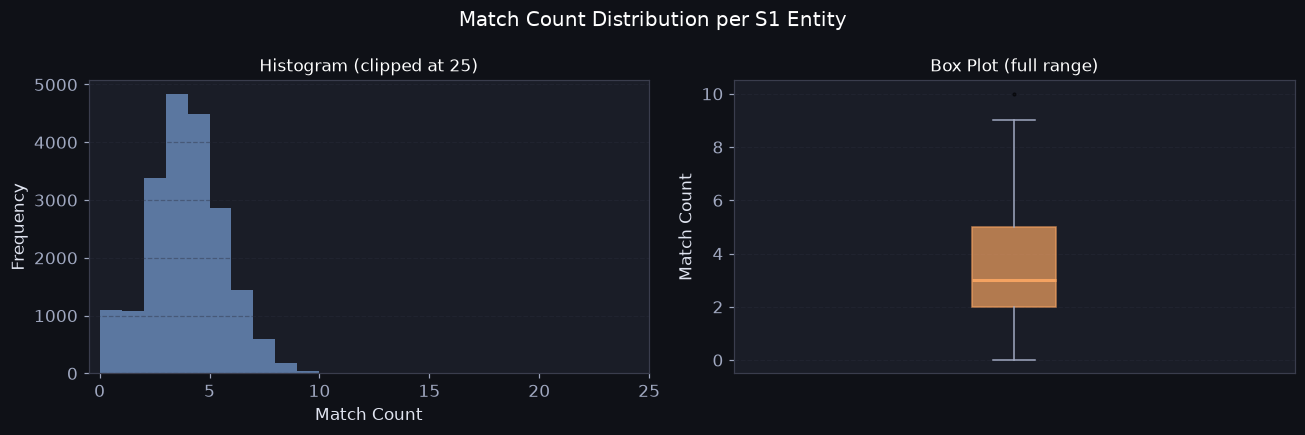

Chart saved: output/eda_match_count_stats.png


18129

In [38]:
# Match count histogram + box plot
VSAMPLE = 20_000
sample_mc = mc.sample(n=min(VSAMPLE, len(mc)), random_state=7).values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Match Count Distribution per S1 Entity',
             fontsize=13, color='#ffffff')

# Histogram
axes[0].hist(sample_mc, bins=range(0, min(int(sample_mc.max())+2, 25)),
             color=PALETTE[0], alpha=0.8)
axes[0].set_title('Histogram (clipped at 25)', fontsize=11)
axes[0].set_xlabel('Match Count'); axes[0].set_ylabel('Frequency')
axes[0].set_xlim(-0.5, 25); axes[0].grid(axis='y', alpha=0.4)

# Box plot
axes[1].boxplot(sample_mc, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[2], color=PALETTE[2], alpha=0.7),
                medianprops=dict(color='#f4a261', linewidth=2),
                whiskerprops=dict(color='#a0a8c0'),
                capprops=dict(color='#a0a8c0'),
                flierprops=dict(marker='.', color='#e76f51', alpha=0.3, markersize=3))
axes[1].set_title('Box Plot (full range)', fontsize=11)
axes[1].set_ylabel('Match Count'); axes[1].set_xticks([])
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('../output/eda_match_count_stats.png',
            dpi=110, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart saved: output/eda_match_count_stats.png')
del mc, sample_mc; gc.collect()

---
## 12. Representative Examples

Display clean text examples for: zero matches, exactly one match, multiple matches, and matches spanning both S2 and S3. Records are loaded selectively without dumping full tables.

In [39]:
zero_ids  = gt.loc[gt['match_count'] == 0,            'source1_entity_id'].head(5).tolist()
one_ids   = gt.loc[gt['match_count'] == 1,            'source1_entity_id'].head(5).tolist()
multi_ids = gt.loc[gt['match_count'] >= 3,            'source1_entity_id'].head(5).tolist()
both_ids  = gt.loc[gt['match_source'] == 'both_S2_S3','source1_entity_id'].head(5).tolist()

print('Category      Sample S1 entity_ids')
print(f'Zero match  : {zero_ids}')
print(f'One match   : {one_ids}')
print(f'Multi match : {multi_ids}')
print(f'Both S2+S3  : {both_ids}')

Category      Sample S1 entity_ids
Zero match  : ['S1-302869473', 'S1-262997549', 'S1-508022910', 'S1-666499407', 'S1-965524997']
One match   : ['S1-116043204', 'S1-473377609', 'S1-439203009', 'S1-973290215', 'S1-649259801']
Multi match : ['S1-965667', 'S1-55344266', 'S1-343815751', 'S1-656753428', 'S1-102811957']
Both S2+S3  : ['S1-965667', 'S1-55344266', 'S1-343815751', 'S1-656753428', 'S1-102811957']


In [40]:
# Load S1 records for representative entity IDs only
all_rep_ids = list(set(zero_ids + one_ids + multi_ids + both_ids))
s1_train = load_source1()
s1_rep   = s1_train[s1_train['entity_id'].isin(all_rep_ids)].copy()
del s1_train; gc.collect()

gt_rep = gt[gt['source1_entity_id'].isin(all_rep_ids)].copy()

def show_examples(eids, label):
    print(f'\n{"="*70}')
    print(f'  {label}')
    print(f'{"="*70}')
    merged = gt_rep[gt_rep['source1_entity_id'].isin(eids)].merge(
        s1_rep[['entity_id', 'business_name', 'business_address', 'country']],
        left_on='source1_entity_id', right_on='entity_id', how='left'
    )
    display(merged[['source1_entity_id', 'business_name', 'country',
                    'match_count', 'match_source', 'matched_entity_ids']]
            .reset_index(drop=True))

show_examples(zero_ids,  '12a. Zero Matches')
show_examples(one_ids,   '12b. Exactly One Match')
show_examples(multi_ids, '12c. Multiple Matches (>=3)')
show_examples(both_ids,  '12d. Matches Spanning Both S2 and S3')

del s1_rep, gt_rep; gc.collect()


  12a. Zero Matches


,source1_entity_id,business_name,country,match_count,match_source,matched_entity_ids
0,S1-302869473,International Automation Consultants Inc,US,0,no_match,NaN
1,S1-262997549,Gabriella's Preferred Security,US,0,no_match,NaN
2,S1-508022910,Twyla's Liquor Corp,US,0,no_match,NaN
3,S1-666499407,Vadapalani Projects Pvt. Ltd.,India,0,no_match,NaN
4,S1-965524997,Campbell Property Solutions,US,0,no_match,NaN



  12b. Exactly One Match


,source1_entity_id,business_name,country,match_count,match_source,matched_entity_ids
0,S1-116043204,Red Consultants Pvt. Ltd.,India,1,S3_only,S3-85523430
1,S1-473377609,Wave & Brothers Ltd,India,1,S3_only,S3-433876173
2,S1-439203009,Ace Producer Private Limited,India,1,S3_only,S3-967165288
3,S1-973290215,Gulf Ministries V Associates,US,1,S3_only,S3-925530888
4,S1-649259801,Guru Solutions Pvt Ltd,India,1,S2_only,S2-654066445



  12c. Multiple Matches (>=3)


,source1_entity_id,business_name,country,match_count,match_source,matched_entity_ids
0,S1-965667,Maure Williams Colombier Inc,US,5,both_S2_S3,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,Raj Investments LLP,India,4,both_S2_S3,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,Dahlia Power Reliable Scientific LLC,US,3,both_S2_S3,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,Ss Food Private Limited,India,3,both_S2_S3,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,Payne Enterprises,US,6,both_S2_S3,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."



  12d. Matches Spanning Both S2 and S3


,source1_entity_id,business_name,country,match_count,match_source,matched_entity_ids
0,S1-965667,Maure Williams Colombier Inc,US,5,both_S2_S3,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,Raj Investments LLP,India,4,both_S2_S3,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,Dahlia Power Reliable Scientific LLC,US,3,both_S2_S3,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,Ss Food Private Limited,India,3,both_S2_S3,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,Payne Enterprises,US,6,both_S2_S3,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."


0

In [41]:
# Selectively pull matching records from S2 and S3 for the both_S2_S3 case
print('Matching records from S2 / S3 for both_S2_S3 examples:')
gt_both = gt[gt['source1_entity_id'].isin(both_ids)].copy()

s2_need, s3_need = [], []
for _, row in gt_both.iterrows():
    for m in row['match_list']:
        if m.startswith('S2-'):   s2_need.append(m)
        elif m.startswith('S3-'): s3_need.append(m)

print(f'  S2 IDs needed: {s2_need}')
print(f'  S3 IDs needed: {s3_need}')

if s2_need:
    s2_train = load_source2()
    display(s2_train[s2_train['entity_id'].isin(s2_need)].reset_index(drop=True))
    del s2_train; gc.collect()

if s3_need:
    s3_train = load_source3()
    display(s3_train[s3_train['entity_id'].isin(s3_need)].reset_index(drop=True))
    del s3_train; gc.collect()

del gt_both, gt; gc.collect()

Matching records from S2 / S3 for both_S2_S3 examples:
  S2 IDs needed: ['S2-681193310', 'S2-743505751', 'S2-249013014', 'S2-197070651', 'S2-790675320', 'S2-479876582', 'S2-153058913', 'S2-24659151', 'S2-478959098', 'S2-553508714', 'S2-625774905']
  S3 IDs needed: ['S3-775321672', 'S3-11291185', 'S3-860443364', 'S3-478195123', 'S3-384364074', 'S3-878454467', 'S3-679606215', 'S3-728090388', 'S3-928796641', 'S3-449308785']


,entity_id,business_name,business_address,country
0,S2-625774905,PAYNE-ENRTPRMISES,"3315 FREMONT SAINT, PEORIA, IL",US
1,S2-478959098,Payne Énterprises,"3315 FREMONT ST, PEORIA, IL",US
2,S2-681193310,Maure Wilblims Colombier Inc,NaN,US
3,S2-553508714,Payne Enterpires,"3315 FREMONT ST, PEORIA, IL",US
4,S2-197070651,Raj Investments LLP,"6(29), C.I.T. COLONY, 2ND MAIN ROAD MYLAPORE, ...",India
5,S2-479876582,Dahlia Power Reliable Scientific,"45ND TERRACE, null, KANSAS CITY, MO",US
6,S2-743505751,Maure Williams Colombier,NaN,US
7,S2-153058913,एसएस फूड प्राइवेट लिमिटेड,"AF-0684, NANDGRAM NEAR MOTHER INDIA PUBLIC SCH...",India
8,S2-790675320,Dahlia Power Reliable,"KANSAS CITY, MO, 630 45ND TERRACE, null",US
9,S2-249013014,ராஜ் இன்வெஸ்ட்மெண்ட்ஸ் எல்எல்பி,"6(29), C.I.T. COLONY, 2ND MAIN ROAD MYLAPORE, ...",India


,entity_id,business_name,business_address,country
0,S3-860443364,Maure Williams Inc Center,NaN,US
1,S3-449308785,Payne Enterprises LLC,"Fremont St, Peoria, Illinois",US
2,S3-384364074,ராஜ் இன்வெஸ்ட்மெண்ட்ஸ் எல்எல்பி,"6(29), C.i.t. Colony, 2Nd Main Road Mylapore, ...",India
3,S3-728090388,Payne Etrepndiels,"3315 Fremont St, Peoria, Illinois",US
4,S3-775321672,Dréxkor,"85 Wanye Avenue, Ticonderoga Townshiip, New York",US
5,S3-478195123,Raj Investments எல்எல்பி,"6(29), C.i.t. Colony, 2Nd Main Road Mylapore, ...",India
6,S3-928796641,Payne Énterprises,"3315 Fremont Street, Peoria, Illinois",US
7,S3-679606215,एसएस फूड प्राइवेट लिमिटेड,"Af-684, Ghaziabad, UP",India
8,S3-878454467,Dahlia Ponr Reliable Scientific LLC,"Missouri, 630 45th Terrace, Kansas City",US
9,S3-11291185,maurewilliamscolombier.com,"Wayne Ave, Ticonderoga Townshiip, New York",US


0

---
# Exploratory Data Analysis Summary

Strictly descriptive summary based directly on executed notebook computations.

---

## 1. Dataset Dimensions & Row Counts

| Dataset | Rows | Columns | In-RAM Size |
|---|---|---|---|
| train_source1 | 2,206,821 | 4 | 633.8 MB |
| train_source2 | 5,034,616 | 4 | 1487.7 MB |
| train_source3 | 5,285,603 | 4 | 1550.3 MB |
| train_ground_truth | 2,206,821 | 2 | 336.8 MB |
| test_source1 | 1,732,544 | 4 | 509.5 MB |
| test_source2 | 4,887,273 | 4 | 1488.7 MB |
| test_source3 | 5,082,316 | 4 | 1523.0 MB |

---

## 2. Missing-Value Statistics

- **`entity_id`**: 0 missing (0.000%) across all 6 datasets.
- **`country`**: 0 missing (0.000%) across all 6 datasets.
- **`business_name`**:
  - train_source1: 0 missing (0.0000%), 0 whitespace-only (0.000%)
  - train_source2: 2 missing (0.00004%), 0 whitespace-only (0.000%)
  - train_source3: 13 missing (0.00025%), 0 whitespace-only (0.000%)
  - test_source1: 0 missing (0.0000%), 0 whitespace-only (0.000%)
  - test_source2: 46 missing (0.00094%), 0 whitespace-only (0.000%)
  - test_source3: 59 missing (0.00116%), 0 whitespace-only (0.000%)
- **`business_address`**:
  - train_source1: 0 missing (0.0000%), 0 whitespace-only (0.000%)
  - train_source2: 168,967 missing (3.3561%), 0 whitespace-only (0.000%)
  - train_source3: 175,916 missing (3.3282%), 0 whitespace-only (0.000%)
  - test_source1: 0 missing (0.0000%), 0 whitespace-only (0.000%)
  - test_source2: 129,408 missing (2.6479%), 0 whitespace-only (0.000%)
  - test_source3: 136,098 missing (2.6779%), 0 whitespace-only (0.000%)

---

## 3. Duplicate Statistics

- **`entity_id` Uniqueness**: 0 duplicate IDs observed across all datasets (100% unique per dataset).
- **`business_name` Repetition**:
  - train_source1: 1,539,229 distinct names; 177,793 occur >1 time (top: Primary Care Group 253x, Ear Nose & Throat Group 251x, Pediatric Group 222x).
  - train_source2: 4,402,008 distinct names; 239,778 occur >1 time (top: Primary Care 320x, Physical Therapy 307x, Urgent Care 297x).
  - train_source3: 4,651,608 distinct names; 258,275 occur >1 time (top: Primary Care 421x, Physical Therapy 399x, Pediatric Dental 393x).
- **`business_address` Repetition**:
  - train_source1: 2,130,606 distinct addresses; 40,089 occur >1 time (top: 108 Norle Street, College Twp, PA 14x).
  - train_source2: 4,337,261 distinct addresses; 421,472 occur >1 time (top: 842 38, CALEDONAI TOWNSHIP, WI 18x).
  - train_source3: 4,632,764 distinct addresses; 382,890 occur >1 time (top: Ground Floor, Bangalore, KA 29x).

---

## 4. Entity ID Prefix Validation Results

Exhaustive chunked validation of all 24,193,173 rows:

| Dataset | Total Rows | Expected Prefix | Observed Prefixes | Anomalies | Status |
|---|---|---|---|---|---|
| train_source1 | 2,206,821 | S1- | [('S1-', 2206821)] | 0 | PASS |
| train_source2 | 5,034,616 | S2- | [('S2-', 5034616)] | 0 | PASS |
| train_source3 | 5,285,603 | S3- | [('S3-', 5285603)] | 0 | PASS |
| test_source1 | 1,732,544 | S1- | [('S1-', 1732544)] | 0 | PASS |
| test_source2 | 4,887,273 | S2- | [('S2-', 4887273)] | 0 | PASS |
| test_source3 | 5,082,316 | S3- | [('S3-', 5082316)] | 0 | PASS |

---

## 5. Country Distributions

| Dataset | US Count (%) | India Count (%) | France Count (%) | Total Rows |
|---|---|---|---|---|
| train_source1 | 1,323,633 (59.98%) | 883,188 (40.02%) | 0 (0.00%) | 2,206,821 |
| train_source2 | 3,016,817 (59.92%) | 2,017,799 (40.08%) | 0 (0.00%) | 5,034,616 |
| train_source3 | 3,170,056 (59.98%) | 2,115,547 (40.02%) | 0 (0.00%) | 5,285,603 |
| test_source1 | 663,106 (38.27%) | 809,986 (46.75%) | 259,452 (14.98%) | 1,732,544 |
| test_source2 | 1,871,330 (38.29%) | 2,312,565 (47.32%) | 703,378 (14.39%) | 4,887,273 |
| test_source3 | 1,945,701 (38.28%) | 2,405,000 (47.32%) | 731,615 (14.40%) | 5,082,316 |

---

## 6. Business Name Statistics

| Source | Non-Null | Min | Max | Mean | Median | p25 | p75 | p95 | p99 |
|---|---|---|---|---|---|---|---|---|---|
| train_source1 | 2,206,821 | 3 | 105 | 24.1 | 24.0 | 18.0 | 30.0 | 37.0 | 42.0 |
| train_source2 | 5,034,614 | 2 | 104 | 25.1 | 25.0 | 18.0 | 31.0 | 40.0 | 48.0 |
| train_source3 | 5,285,590 | 2 | 123 | 25.2 | 25.0 | 18.0 | 31.0 | 42.0 | 50.0 |
| test_source1 | 1,732,544 | 3 | 92 | 23.8 | 24.0 | 18.0 | 29.0 | 36.0 | 42.0 |
| test_source2 | 4,887,227 | 2 | 102 | 25.7 | 25.0 | 19.0 | 32.0 | 41.0 | 49.0 |
| test_source3 | 5,082,257 | 2 | 103 | 25.6 | 25.0 | 19.0 | 32.0 | 42.0 | 50.0 |

- Names <= 5 characters in train_source1: 6,252 (e.g., `Meon`, `Proum`, `Faor`, `Buus`, `Minoo`, `Meex`, `Ceque`, `Peum`).
- Names >= 200 characters: 0 across all sources (max observed: 123 chars in train_source3).

---

## 7. Address Statistics

| Source | Non-Null | Null | No Digit (%) | All Uppercase (%) | Min | Max | Mean | Median | p25 | p75 | p95 |
|---|---|---|---|---|---|---|---|---|---|---|---|
| train_source1 | 2,206,821 | 0 | 77,037 (3.49%) | 4 (0.00%) | 11 | 256 | 52.1 | 41.0 | 33.0 | 70.0 | 103.0 |
| train_source2 | 4,865,649 | 168,967 | 301,974 (6.00%) | 3,191,104 (63.38%) | 8 | 249 | 47.9 | 37.0 | 31.0 | 63.0 | 97.0 |
| train_source3 | 5,109,687 | 175,916 | 310,390 (5.87%) | 813 (0.02%) | 2 | 240 | 48.4 | 42.0 | 35.0 | 55.0 | 92.0 |
| test_source1 | 1,732,544 | 0 | 71,838 (4.15%) | 2 (0.00%) | 11 | 268 | 57.1 | 50.0 | 36.0 | 74.0 | 105.0 |
| test_source2 | 4,757,865 | 129,408 | 228,622 (4.68%) | 2,448,518 (50.10%) | 5 | 269 | 51.8 | 43.0 | 32.0 | 68.0 | 99.0 |
| test_source3 | 4,946,218 | 136,098 | 245,395 (4.83%) | 914 (0.02%) | 5 | 267 | 50.0 | 44.0 | 36.0 | 59.0 | 94.0 |

---

## 8. Ground-Truth Match-Count Distribution

| Match Count Bucket | Entity Count | Percentage |
|---|---|---|
| 0 | 123,247 | 5.585% |
| 1 | 119,157 | 5.399% |
| 2 | 375,212 | 17.002% |
| 3 | 530,841 | 24.055% |
| 4+ | 1,058,364 | 47.959% |
| **Total S1 Entities** | **2,206,821** | **100.000%** |

---

## 9. Match Source Distribution

| Category | S1 Entity Count | Percentage |
|---|---|---|
| both_S2_S3 | 1,776,047 | 80.480% |
| S3_only | 164,498 | 7.454% |
| S2_only | 143,029 | 6.481% |
| no_match | 123,247 | 5.585% |
| **Total** | **2,206,821** | **100.000%** |

---

## 10. Match Count Summary Statistics

- Total S1 entities: 2,206,821
- Total match pairs: 7,638,365
- Mean matches per S1 entity: 3.4613
- Standard deviation: 1.7053
- Minimum: 0
- 10th Percentile (p10): 1.0
- 25th Percentile (p25): 2.0
- Median (p50): 3.0
- 75th Percentile (p75): 5.0
- 90th Percentile (p90): 6.0
- 95th Percentile (p95): 6.0
- 99th Percentile (p99): 8.0
- Maximum: 11
- Entities with match count > p99 (8): 4,776

---

## 11. Representative Examples

### Zero Matches (match_count = 0)
- `S1-302869473` | `International Automation Consultants Inc` | US
- `S1-262997549` | `Gabriella's Preferred Security` | US
- `S1-508022910` | `Twyla's Liquor Corp` | US
- `S1-666499407` | `Vadapalani Projects Pvt. Ltd.` | India
- `S1-965524997` | `Campbell Property Solutions` | US

### Exactly One Match (match_count = 1)
- `S1-116043204` | `Red Consultants Pvt. Ltd.` | India | S3_only: `S3-85523430`
- `S1-473377609` | `Wave & Brothers Ltd` | India | S3_only: `S3-433876173`
- `S1-439203009` | `Ace Producer Private Limited` | India | S3_only: `S3-967165288`
- `S1-973290215` | `Gulf Ministries V Associates` | US | S3_only: `S3-925530888`
- `S1-649259801` | `Guru Solutions Pvt Ltd` | India | S2_only: `S2-654066445`

### Matches Spanning Both S2 and S3 (both_S2_S3)
- `S1-965667` (`Maure Williams Colombier Inc`, US, 5 matches):
  - S2: `S2-681193310` (`Maure Wilblims Colombier Inc`), `S2-743505751` (`Maure Williams Colombier`)
  - S3: `S3-860443364` (`Maure Williams Inc Center`), `S3-775321672` (`Dréxkor`), `S3-11291185` (`maurewilliamscolombier.com`)
- `S1-55344266` (`Raj Investments LLP`, India, 4 matches):
  - S2: `S2-197070651` (`Raj Investments LLP`), `S2-249013014` (`ராஜ் இன்வெஸ்ட்மெண்ட்ஸ் எல்எல்பி`)
  - S3: `S3-384364074` (`ராஜ் இன்வெஸ்ட்மெண்ட்ஸ் எல்எல்பி`), `S3-478195123` (`Raj Investments எல்எல்பி`)
- `S1-343815751` (`Dahlia Power Reliable Scientific LLC`, US, 3 matches):
  - S2: `S2-479876582` (`Dahlia Power Reliable Scientific`), `S2-790675320` (`Dahlia Power Reliable`)
  - S3: `S3-878454467` (`Dahlia Ponr Reliable Scientific LLC`)
- `S1-656753428` (`Ss Food Private Limited`, India, 3 matches):
  - S2: `S2-153058913` (`एसएस फूड प्राइवेट लिमिटेड`), `S2-24659151` (`एसएस फूड प्राइवेट लिमिटेड`)
  - S3: `S3-679606215` (`एसएस फूड प्राइवेट लिमिटेड`)
- `S1-102811957` (`Payne Enterprises`, US, 6 matches):
  - S2: `S2-625774905` (`PAYNE-ENRTPRMISES`), `S2-478959098` (`Payne Énterprises`), `S2-553508714` (`Payne Enterpires`)
  - S3: `S3-449308785` (`Payne Enterprises  LLC`), `S3-728090388` (`Payne Etrepndiels`), `S3-928796641` (`Payne Énterprises`)

---

## 12. Factual Data-Quality Observations Directly Supported by Results

1. **Discrepancy in Country Vocabularies Between Splits**: Training datasets strictly contain 2 country labels (`US`: ~59.95%, `India`: ~40.05%). Test datasets contain an additional country label (`France`: ~14.5% across test sources, with `India`: ~47.1% and `US`: ~38.3%).
2. **Address Missingness Asymmetry**: `train_source1` and `test_source1` have zero missing address values (0.000%). `train_source2` (3.356%), `train_source3` (3.328%), `test_source2` (2.648%), and `test_source3` (2.678%) have non-zero missing address values.
3. **Address Casing Asymmetry**: Over 63% of addresses in `train_source2` (3,191,104 rows) and over 50% in `test_source2` (2,448,518 rows) are formatted in all-uppercase characters, compared to 4 rows in `train_source1` and 813 in `train_source3`.
4. **Addresses Without Numeric Characters**: In all 6 datasets, a proportion of addresses contains zero digit characters (3.49% in `train_source1`, 6.00% in `train_source2`, 5.87% in `train_source3`, 4.15% in `test_source1`, 4.68% in `test_source2`, 4.83% in `test_source3`).
5. **Multi-Script Entity Matches**: Match clusters for Indian entities contain business names recorded in multiple writing scripts, including Latin script, Tamil script, and Devanagari script for the same entity.
6. **ID Format Integrity**: All 24,193,173 entity IDs across all 6 datasets have 0 anomalies against their expected source prefix (`S1-`, `S2-`, `S3-`) and 0 duplicate IDs within any single source file.


In [42]:
# Final cleanup
gc.collect()
print('EDA notebook complete.')
print('All intermediate DataFrames have been released.')
print('Charts saved under: ../output/eda_*.png')

EDA notebook complete.
All intermediate DataFrames have been released.
Charts saved under: ../output/eda_*.png
